# Benchmark công thức $C_{ij}$ với các phương pháp phân cụm khác

Mục tiêu: đánh giá **Product-$C_{ij}$ + Louvain** so với các baseline được tuning riêng, đồng thời chạy sensitivity analysis Product–Additive ở mật độ graph tương đương.

- Development: `run_001`–`run_020` (kiểm tra dữ liệu/code).
- Calibration: `run_021`–`run_040` (chọn cấu hình riêng bằng mean ARI).
- Benchmark test: `run_041`–`run_080` (khóa cấu hình rồi chấm đúng một lượt).

20 development run chỉ dùng để audit schema/khả năng chạy code, không dùng chọn tham số. Mọi phương pháp chỉ nhận `algorithm_input.json`. Trong test, toàn bộ prediction được tạo xong trước khi mở `ground_truth.json`. `latent_incidents.json` và `observable_reports.json` không được đọc. Vì kết quả tổng hợp 80 run đã từng được quan sát trong quá trình phát triển, 40 run cuối là **benchmark test split**, không được gọi là held-out hoàn toàn chưa từng quan sát.

Notebook này chỉ đánh giá **clustering**. Nó không dùng kết quả clustering để tuyên bố công thức priority tốt; priority cần một benchmark riêng với outcome độc lập.


In [1]:
from google.colab import drive
from pathlib import Path
import zipfile

drive.mount('/content/drive')
DRIVE_DATA_DIR = Path('/content/drive/MyDrive/Colab Notebooks/data')
DATA_ZIP_NAME = 'flood_hybrid_EMSR848_80_runs (1).zip'
DATA_ZIP = DRIVE_DATA_DIR / DATA_ZIP_NAME
DATA_WORK = Path('/content/cij_baseline_benchmark_data')
RESULTS_ROOT = DRIVE_DATA_DIR / 'cij_baseline_benchmark_results'

assert DATA_ZIP.is_file(), f'Không tìm thấy {DATA_ZIP}'
if not list(DATA_WORK.rglob('run_001/algorithm_input.json')):
    DATA_WORK.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(DATA_ZIP) as archive:
        archive.extractall(DATA_WORK)
run_dirs = sorted(path.parent for path in DATA_WORK.rglob('run_*/algorithm_input.json'))
assert len(run_dirs) == 80 and run_dirs[0].name == 'run_001' and run_dirs[-1].name == 'run_080'
DEV_RUNS, CAL_RUNS, TEST_RUNS = run_dirs[:20], run_dirs[20:40], run_dirs[40:]
assert not (set(DEV_RUNS) & set(CAL_RUNS) or set(DEV_RUNS) & set(TEST_RUNS) or set(CAL_RUNS) & set(TEST_RUNS))
RESULTS_ROOT.mkdir(parents=True, exist_ok=True)
print('Split:', len(DEV_RUNS), len(CAL_RUNS), len(TEST_RUNS))
print('Calibration:', CAL_RUNS[0].name, '→', CAL_RUNS[-1].name)
print('Test:', TEST_RUNS[0].name, '→', TEST_RUNS[-1].name)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Split: 20 20 40
Calibration: run_021 → run_040
Test: run_041 → run_080


In [2]:
# Cài dependency và tự restart kernel đúng một lần nếu cần thay NumPy.
import importlib.metadata as package_metadata
import os, subprocess, sys
from pathlib import Path
assert sys.version_info[:2] == (3, 12), 'Hãy chọn runtime Python 3.12.'
REQUIRED = {
    'numpy':'2.5.1', 'pandas':'3.0.3', 'matplotlib':'3.11.0',
    'networkx':'3.6.1', 'python-louvain':'0.16',
    'scikit-learn':'1.9.0', 'scipy':'1.18.0',
    'igraph':'1.0.0', 'leidenalg':'0.12.0',
}
MARKER = Path('/content/.cij_baseline_dependencies_v1')
if not MARKER.is_file():
    specs = [f'{name}=={version}' for name, version in REQUIRED.items()]
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', '--upgrade',
                    '--upgrade-strategy', 'only-if-needed', *specs], check=True)
    MARKER.write_text('ready', encoding='utf-8')
    print('Đã cài xong; Colab tự restart. Kết nối lại rồi Run all lần nữa.')
    os.kill(os.getpid(), 9)
installed = {name: package_metadata.version(name) for name in REQUIRED}
assert installed == REQUIRED, f'Phiên bản không khớp: {installed}'
subprocess.run([sys.executable, '-c', 'import numpy,scipy,sklearn,community,igraph,leidenalg'], check=True)
print('PASS dependencies:', installed)


PASS dependencies: {'numpy': '2.5.1', 'pandas': '3.0.3', 'matplotlib': '3.11.0', 'networkx': '3.6.1', 'python-louvain': '0.16', 'scikit-learn': '1.9.0', 'scipy': '1.18.0', 'igraph': '1.0.0', 'leidenalg': '0.12.0'}


## Phương pháp và ngân sách tuning

| ID | Vai trò | Số cấu hình |
|---|---|---:|
| `product_cij_louvain` | phương pháp đề xuất | 16 |
| `additive_cij_louvain` | đối chứng phép cộng cùng $G,T,C$ | 16 |
| `convex_cij_louvain` | hỗn hợp cộng chuẩn hóa linh hoạt | 12 |
| `geo_time_dbscan` | DBSCAN lân cận kết hợp địa lý–thời gian; không gọi ST-DBSCAN đầy đủ | 12 |
| `dbscan_all` | DBSCAN trên mọi feature quan sát | 12 |
| `hdbscan_all` | HDBSCAN trên mọi feature quan sát | 16 |
| `spatial_agglomerative` | phân cụm phân cấp có connectivity địa lý, preset $K$ từ calibration | 20 |
| `coordinate_kmeans` | diagnostic chỉ dùng tọa độ, preset $K$ từ calibration | 5 |
| `product_cij_leiden` | cùng graph đề xuất, đổi Louvain thành Leiden | 4 resolution |

Số cấu hình không hoàn toàn bằng nhau vì mỗi thuật toán có số núm khác nhau; mọi grid đều nhỏ, được ghi rõ và chạy hết, không dừng khi thấy kết quả thuận lợi. Grid $K=\{8,12,16,20,24\}$ được chọn trên calibration rồi khóa trước test; K-Means vẫn chỉ là diagnostic yếu, không phải đối thủ tương đương.


In [3]:
import itertools, json, math, time
from collections import Counter
from datetime import datetime

import igraph as ig
import leidenalg
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
from community import community_louvain
from scipy.sparse import csr_matrix
from scipy.stats import wilcoxon
from sklearn.cluster import AgglomerativeClustering, DBSCAN, HDBSCAN, KMeans
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from sklearn.preprocessing import RobustScaler, StandardScaler

TAU_F, TAU_E = 0.25, 0.35
BETA, GAMMA = 0.5, 0.5
FORMULA_VERSION = 'paper-missing-aware-cij-v1'

def read_json(path):
    return json.loads(Path(path).read_text(encoding='utf-8'))

def load_input(run_dir):
    payload = read_json(run_dir / 'algorithm_input.json')
    rows = payload['reports']
    lat = np.radians(np.array([float(r['lat']) for r in rows]))
    lng = np.radians(np.array([float(r['lng']) for r in rows]))
    lat0, lng0 = np.median(lat), np.median(lng)
    east = 6_371_000.0 * np.cos(lat0) * (lng - lng0)
    north = 6_371_000.0 * (lat - lat0)
    minute = np.array([datetime.fromisoformat(r['created_at']).timestamp()/60 for r in rows])
    minute = minute - minute.min()
    flood = np.array([float(r['flood']) for r in rows])
    urgency = np.array([float(r['urgency']) for r in rows])
    obs_f = np.array(['flood' not in r.get('missing_fields', []) for r in rows])
    obs_e = np.array(['urgency' not in r.get('missing_fields', []) for r in rows])
    return {'dataset_id':payload['dataset_id'], 'seed':int(payload['seed']),
            'event_id':[r['event_id'] for r in rows], 'lat_rad':lat, 'lng_rad':lng,
            'east':east, 'north':north, 'minute':minute, 'flood':flood,
            'urgency':urgency, 'obs_f':obs_f, 'obs_e':obs_e}

def load_truth(run_dir, event_ids):
    payload = read_json(run_dir / 'ground_truth.json')
    by_id = {r['event_id']:int(r['gt_cluster']) for r in payload['report_labels']}
    assert set(by_id) == set(event_ids)
    return np.array([by_id[eid] for eid in event_ids])

def pair_matrices(x):
    lat,lng=x['lat_rad'],x['lng_rad']
    dlat=lat[:,None]-lat[None,:]; dlng=lng[:,None]-lng[None,:]
    hav=np.sin(dlat/2)**2+np.cos(lat)[:,None]*np.cos(lat)[None,:]*np.sin(dlng/2)**2
    distance=2*6_371_000.0*np.arcsin(np.sqrt(np.clip(hav,0,1)))
    dt=np.abs(x['minute'][:,None]-x['minute'][None,:])
    i_f=(x['obs_f'][:,None]&x['obs_f'][None,:]).astype(float)
    i_e=(x['obs_e'][:,None]&x['obs_e'][None,:]).astype(float)
    m=i_f+i_e
    cij=(m/2)*np.exp(-i_f*np.abs(x['flood'][:,None]-x['flood'][None,:])/TAU_F
                        -i_e*np.abs(x['urgency'][:,None]-x['urgency'][None,:])/TAU_E)
    cij[m==0]=0; np.fill_diagonal(cij,0)
    return distance,dt,cij

def threshold_knn(w, quantile, knn):
    out=w.copy(); np.fill_diagonal(out,0)
    values=out[np.triu_indices(len(out),1)]; values=values[values>0]
    theta=float(np.quantile(values,quantile)) if len(values) else math.inf
    out[out<=theta]=0
    if 0<knn<len(out):
        mask=np.zeros_like(out,dtype=bool)
        for i,row in enumerate(out):
            top=np.argpartition(row,-knn)[-knn:] if np.count_nonzero(row)>knn else np.nonzero(row)[0]
            mask[i,top]=True
        out=np.where(mask|mask.T,out,0)
    np.fill_diagonal(out,0); return out

def louvain(w,resolution):
    g=nx.Graph(); g.add_nodes_from(range(len(w)))
    a,b=np.nonzero(np.triu(w,1)); g.add_weighted_edges_from((int(i),int(j),float(w[i,j])) for i,j in zip(a,b))
    if not g.number_of_edges(): return np.arange(len(w))
    part=community_louvain.best_partition(g,weight='weight',resolution=resolution,random_state=42)
    return np.array([part.get(i,i) for i in range(len(w))])

def leiden(w,resolution):
    a,b=np.nonzero(np.triu(w,1)); edges=list(zip(a.tolist(),b.tolist()))
    if not edges:return np.arange(len(w))
    g=ig.Graph(n=len(w),edges=edges); g.es['weight']=[float(w[i,j]) for i,j in edges]
    part=leidenalg.find_partition(g,leidenalg.RBConfigurationVertexPartition,
        weights='weight',resolution_parameter=resolution,seed=42)
    labels=np.zeros(len(w),dtype=int)
    for cid,members in enumerate(part): labels[list(members)]=cid
    return labels

def scaled_features(x,scaler):
    raw=np.column_stack([x['east'],x['north'],x['minute'],x['flood'],x['urgency']])
    return (RobustScaler() if scaler=='robust' else StandardScaler()).fit_transform(raw)

def graph_stats(w):
    n=len(w); n_edges=int(np.count_nonzero(np.triu(w,1)))
    total=n*(n-1)/2
    return {'n_edges':n_edges,
            'retained_edge_fraction':float(n_edges/total) if total else 0.0,
            'mean_degree':float(2*n_edges/n) if n else 0.0}

# Unit test bắt buộc cho ba nhánh m_ij=2,1,0 của công thức paper.
toy={'lat_rad':np.zeros(4),'lng_rad':np.zeros(4),'minute':np.zeros(4),
     'flood':np.array([.2,.5,.5,.5]),'urgency':np.array([.8,.1,.1,.1]),
     'obs_f':np.array([True,True,True,False]),'obs_e':np.array([True,True,False,False])}
_,_,toy_cij=pair_matrices(toy)
assert np.isclose(toy_cij[0,1],math.exp(-.3/TAU_F-.7/TAU_E))
assert np.isclose(toy_cij[0,2],.5*math.exp(-.3/TAU_F))
assert toy_cij[0,3]==0.0
print('PASS C_ij: đúng các nhánh m_ij = 2, 1, 0')


PASS C_ij: đúng các nhánh m_ij = 2, 1, 0


In [4]:
def predict(method,x,pairs,cfg,selected_product=None,return_graph=False):
    distance,dt,cij=pairs
    if method in {'product_cij_louvain','additive_cij_louvain',
                'additive_cij_louvain_matched_density','convex_cij_louvain'}:
        geo=np.exp(-(distance**2)/(2*cfg.get('sigma',900)**2))
        temp=np.exp(-dt/cfg.get('tau_t',60))
        if method=='product_cij_louvain': w=geo*(BETA*temp+GAMMA*cij)
        elif method in {'additive_cij_louvain','additive_cij_louvain_matched_density'}:
            w=cfg['alpha']*geo+BETA*temp+GAMMA*cij
        else:
            weights=np.array(cfg['mix']); w=weights[0]*geo+weights[1]*temp+weights[2]*cij
        graph=threshold_knn(w,cfg['q'],cfg['knn'])
        labels=louvain(graph,cfg.get('resolution',1.2))
        return (labels,graph) if return_graph else labels
    if method=='product_cij_leiden':
        base=selected_product; geo=np.exp(-(distance**2)/(2*base['sigma']**2)); temp=np.exp(-dt/base['tau_t'])
        w=threshold_knn(geo*(BETA*temp+GAMMA*cij),base['q'],base['knn'])
        labels=leiden(w,cfg['resolution'])
        return (labels,w) if return_graph else labels
    if method=='geo_time_dbscan':
        dis=np.maximum(distance/cfg['spatial_eps'],dt/cfg['temporal_eps']); np.fill_diagonal(dis,0)
        labels=DBSCAN(eps=1.0,min_samples=cfg['min_samples'],metric='precomputed').fit_predict(dis)
        return (labels,None) if return_graph else labels
    if method=='dbscan_all':
        labels=DBSCAN(eps=cfg['eps'],min_samples=cfg['min_samples']).fit_predict(scaled_features(x,cfg['scaler']))
        return (labels,None) if return_graph else labels
    if method=='hdbscan_all':
        labels=HDBSCAN(min_cluster_size=cfg['min_cluster_size'],min_samples=cfg['min_samples']).fit_predict(scaled_features(x,cfg['scaler']))
        return (labels,None) if return_graph else labels
    if method=='spatial_agglomerative':
        connectivity=csr_matrix((distance<=cfg['radius']).astype(int)); features=scaled_features(x,'standard')
        labels=AgglomerativeClustering(n_clusters=cfg['k'],linkage='ward',connectivity=connectivity).fit_predict(features)
        return (labels,None) if return_graph else labels
    if method=='coordinate_kmeans':
        labels=KMeans(n_clusters=cfg['k'],n_init=10,random_state=42).fit_predict(np.column_stack([x['east'],x['north']]))
        return (labels,None) if return_graph else labels
    raise ValueError(method)

GRIDS={
 'product_cij_louvain':[dict(sigma=s,tau_t=t,q=q,knn=k,resolution=1.2) for s,t,q,k in itertools.product([700,1200],[30,60],[.90,.95],[8,16])],
 'additive_cij_louvain':[dict(alpha=a,sigma=s,tau_t=60,q=q,knn=k,resolution=1.2) for a,s,q,k in itertools.product([1/3,1.0],[700,1200],[.90,.95],[8,16])],
 'convex_cij_louvain':[dict(mix=m,sigma=900,tau_t=60,q=q,knn=k,resolution=1.2) for m,q,k in itertools.product([(1/3,1/3,1/3),(.6,.2,.2),(.2,.4,.4)],[.90,.95],[8,16])],
 'geo_time_dbscan':[dict(spatial_eps=s,temporal_eps=t,min_samples=m) for s,t,m in itertools.product([800,1200,1800],[60,120],[3,5])],
 'dbscan_all':[dict(eps=e,min_samples=m,scaler=s) for e,m,s in itertools.product([.35,.6,1.0],[3,5],['standard','robust'])],
 'hdbscan_all':[dict(min_cluster_size=c,min_samples=m,scaler=s) for c,m,s in itertools.product([3,5,8,12],[None,3],['standard','robust'])],
 'spatial_agglomerative':[dict(radius=r,k=k) for r,k in itertools.product([800,1200,1800,2500],[8,12,16,20,24])],
 'coordinate_kmeans':[dict(k=k) for k in [8,12,16,20,24]],
}
print({method:len(grid) for method,grid in GRIDS.items()})


{'product_cij_louvain': 16, 'additive_cij_louvain': 16, 'convex_cij_louvain': 12, 'geo_time_dbscan': 12, 'dbscan_all': 12, 'hdbscan_all': 16, 'spatial_agglomerative': 20, 'coordinate_kmeans': 5}


In [5]:
def quality(labels,truth):
    keep=truth>=0
    return float(adjusted_rand_score(truth[keep],labels[keep]))

# Development chỉ audit schema và khả năng dựng C_ij, tuyệt đối không đọc ground truth.
dev_audit=[]
for run_dir in DEV_RUNS:
    x=load_input(run_dir); distance,dt,cij=pair_matrices(x)
    assert np.isfinite(distance).all() and np.isfinite(dt).all() and np.isfinite(cij).all()
    dev_audit.append({'run_id':run_dir.name,'n_reports':len(x['event_id']),
                      'missing_f_rate':float(np.mean(~x['obs_f'])),
                      'missing_e_rate':float(np.mean(~x['obs_e']))})
DEV_AUDIT_PATH=RESULTS_ROOT/'development_schema_audit.csv'
pd.DataFrame(dev_audit).to_csv(DEV_AUDIT_PATH,index=False)
print('PASS development audit: 20 run, không đọc ground truth')

# Calibration label-aware: chạy hết grid và chọn mean ARI cao nhất; tie-break bằng std rồi JSON config.
cal_data=[]
for run_dir in CAL_RUNS:
    x=load_input(run_dir); pairs=pair_matrices(x); truth=load_truth(run_dir,x['event_id'])
    cal_data.append((run_dir.name,x,pairs,truth))

selected={}; tuning_rows=[]
for method,grid in GRIDS.items():
    print('Tuning',method,len(grid),'configs')
    candidates=[]
    for ci,cfg in enumerate(grid,1):
        scores=[quality(predict(method,x,pairs,cfg),truth) for _,x,pairs,truth in cal_data]
        row={'method':method,'config_index':ci,'config_json':json.dumps(cfg,sort_keys=True),
             'mean_ari':float(np.mean(scores)),'std_ari':float(np.std(scores,ddof=1))}
        candidates.append((row,cfg)); tuning_rows.append(row)
    best=min(candidates,key=lambda item:(-item[0]['mean_ari'],item[0]['std_ari'],item[0]['config_json']))
    selected[method]=best[1]; print(' selected',best[0])

# Leiden dùng đúng graph product đã chọn, chỉ tuning partition resolution.
leiden_candidates=[]
for ci,resolution in enumerate([.8,1.0,1.2,1.4],1):
    cfg={'resolution':resolution}
    scores=[quality(predict('product_cij_leiden',x,pairs,cfg,selected['product_cij_louvain']),truth)
            for _,x,pairs,truth in cal_data]
    row={'method':'product_cij_leiden','config_index':ci,'config_json':json.dumps(cfg),
         'mean_ari':float(np.mean(scores)),'std_ari':float(np.std(scores,ddof=1))}
    leiden_candidates.append((row,cfg)); tuning_rows.append(row)
best=min(leiden_candidates,key=lambda item:(-item[0]['mean_ari'],item[0]['std_ari'],item[0]['config_json']))
selected['product_cij_leiden']=best[1]

# Matched-density sensitivity: chọn q/k của Additive chỉ bằng mật độ graph, không nhìn ARI.
product_density=[]
for _,x,pairs,_ in cal_data:
    _,graph=predict('product_cij_louvain',x,pairs,selected['product_cij_louvain'],return_graph=True)
    product_density.append(graph_stats(graph))
ref_fraction=np.array([row['retained_edge_fraction'] for row in product_density])
ref_degree=np.array([row['mean_degree'] for row in product_density])
density_candidates=[]
product_cfg=selected['product_cij_louvain']
base_additive={'alpha':0.5,'sigma':product_cfg['sigma'],'tau_t':product_cfg['tau_t'],
               'resolution':product_cfg['resolution']}  # cùng primitive scales; alpha=beta=gamma=0.5
for q,knn in itertools.product(np.linspace(.80,.99,20),[4,8,12,16,24]):
    cfg={**base_additive,'q':float(q),'knn':int(knn)}
    stats=[]
    for _,x,pairs,_ in cal_data:
        _,graph=predict('additive_cij_louvain_matched_density',x,pairs,cfg,return_graph=True)
        stats.append(graph_stats(graph))
    fractions=np.array([row['retained_edge_fraction'] for row in stats])
    degrees=np.array([row['mean_degree'] for row in stats])
    loss=float(np.mean(np.abs(fractions-ref_fraction)/(ref_fraction+1e-12))
               +np.mean(np.abs(degrees-ref_degree)/(ref_degree+1e-12)))
    density_candidates.append({'config':cfg,'density_match_loss':loss,
      'mean_retained_fraction':float(fractions.mean()),'mean_degree':float(degrees.mean())})
density_best=min(density_candidates,key=lambda row:(row['density_match_loss'],json.dumps(row['config'],sort_keys=True)))
selected['additive_cij_louvain_matched_density']=density_best['config']
MATCH_CAL_PATH=RESULTS_ROOT/'matched_density_calibration.csv'
pd.DataFrame([{**{k:v for k,v in row.items() if k!='config'},
               'config_json':json.dumps(row['config'],sort_keys=True)}
              for row in density_candidates]).to_csv(MATCH_CAL_PATH,index=False)
print('Product calibration density:',float(ref_fraction.mean()),float(ref_degree.mean()))
print('Selected Additive matched-density:',density_best)

TUNING_PATH=RESULTS_ROOT/'calibration_grid_results.csv'
CONFIG_PATH=RESULTS_ROOT/'selected_configs.json'
pd.DataFrame(tuning_rows).to_csv(TUNING_PATH,index=False)
CONFIG_PATH.write_text(json.dumps({'formula_version':FORMULA_VERSION,'selected':selected},indent=2),encoding='utf-8')
display(pd.DataFrame([{'method':m,'selected_config':json.dumps(c,sort_keys=True)} for m,c in selected.items()]))


PASS development audit: 20 run, không đọc ground truth
Tuning product_cij_louvain 16 configs
 selected {'method': 'product_cij_louvain', 'config_index': 5, 'config_json': '{"knn": 8, "q": 0.9, "resolution": 1.2, "sigma": 700, "tau_t": 60}', 'mean_ari': 0.9010756988936158, 'std_ari': 0.07847702448614867}
Tuning additive_cij_louvain 16 configs
 selected {'method': 'additive_cij_louvain', 'config_index': 11, 'config_json': '{"alpha": 1.0, "knn": 8, "q": 0.95, "resolution": 1.2, "sigma": 700, "tau_t": 60}', 'mean_ari': 0.9083908765884822, 'std_ari': 0.07158237264892908}
Tuning convex_cij_louvain 12 configs
 selected {'method': 'convex_cij_louvain', 'config_index': 5, 'config_json': '{"knn": 8, "mix": [0.6, 0.2, 0.2], "q": 0.9, "resolution": 1.2, "sigma": 900, "tau_t": 60}', 'mean_ari': 0.9074930618855561, 'std_ari': 0.06986638343848772}
Tuning geo_time_dbscan 12 configs
 selected {'method': 'geo_time_dbscan', 'config_index': 1, 'config_json': '{"min_samples": 3, "spatial_eps": 800, "tempor

/usr/local/lib/python3.12/dist-packages/sklearn/cluster/_hdbscan/hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/cluster/_hdbscan/hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/cluster/_hdbscan/hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/cluster/_hdbscan/hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/cluster/_hdbscan/hdbscan.py:

 selected {'method': 'hdbscan_all', 'config_index': 8, 'config_json': '{"min_cluster_size": 5, "min_samples": 3, "scaler": "robust"}', 'mean_ari': 0.4941467061993789, 'std_ari': 0.20986688306769785}
Tuning spatial_agglomerative 20 configs


/usr/local/lib/python3.12/dist-packages/sklearn/cluster/_agglomerative.py:324: UserWarning: the number of connected components of the connectivity matrix is 10 > 1. Completing it to avoid stopping the tree early.
  connectivity, n_connected_components = _fix_connectivity(
/usr/local/lib/python3.12/dist-packages/sklearn/cluster/_agglomerative.py:324: UserWarning: the number of connected components of the connectivity matrix is 13 > 1. Completing it to avoid stopping the tree early.
  connectivity, n_connected_components = _fix_connectivity(
/usr/local/lib/python3.12/dist-packages/sklearn/cluster/_agglomerative.py:324: UserWarning: the number of connected components of the connectivity matrix is 13 > 1. Completing it to avoid stopping the tree early.
  connectivity, n_connected_components = _fix_connectivity(
/usr/local/lib/python3.12/dist-packages/sklearn/cluster/_agglomerative.py:324: UserWarning: the number of connected components of the connectivity matrix is 10 > 1. Completing it to

 selected {'method': 'spatial_agglomerative', 'config_index': 13, 'config_json': '{"k": 16, "radius": 1800}', 'mean_ari': 0.5999056578802238, 'std_ari': 0.08862361111372073}
Tuning coordinate_kmeans 5 configs
 selected {'method': 'coordinate_kmeans', 'config_index': 4, 'config_json': '{"k": 20}', 'mean_ari': 0.792336913039816, 'std_ari': 0.0995092884375802}
Product calibration density: 0.030304847746543562 9.877592199367207
Selected Additive matched-density: {'config': {'alpha': 0.5, 'sigma': 700, 'tau_t': 60, 'resolution': 1.2, 'q': 0.89, 'knn': 8}, 'density_match_loss': 0.008909323665134385, 'mean_retained_fraction': 0.03040431526855532, 'mean_degree': 9.909353801321819}


,method,selected_config
0,product_cij_louvain,"{""knn"": 8, ""q"": 0.9, ""resolution"": 1.2, ""sigma..."
1,additive_cij_louvain,"{""alpha"": 1.0, ""knn"": 8, ""q"": 0.95, ""resolutio..."
2,convex_cij_louvain,"{""knn"": 8, ""mix"": [0.6, 0.2, 0.2], ""q"": 0.9, ""..."
3,geo_time_dbscan,"{""min_samples"": 3, ""spatial_eps"": 800, ""tempor..."
4,dbscan_all,"{""eps"": 0.35, ""min_samples"": 3, ""scaler"": ""rob..."
5,hdbscan_all,"{""min_cluster_size"": 5, ""min_samples"": 3, ""sca..."
6,spatial_agglomerative,"{""k"": 16, ""radius"": 1800}"
7,coordinate_kmeans,"{""k"": 20}"
8,product_cij_leiden,"{""resolution"": 1.4}"
9,additive_cij_louvain_matched_density,"{""alpha"": 0.5, ""knn"": 8, ""q"": 0.89, ""resolutio..."


In [6]:
def pairwise_f1(labels,truth,noise_label=None):
    keep=truth>=0; labels=np.asarray(labels)[keep]; truth=truth[keep]
    u=np.triu_indices(len(truth),1); a=(truth[:,None]==truth[None,:])[u]
    same=(labels[:,None]==labels[None,:])
    if noise_label is not None:
        rejected=labels==noise_label
        same &= ~(rejected[:,None]|rejected[None,:])  # mỗi rejected report là một unresolved unit
    p=same[u]
    tp=np.sum(a&p); fp=np.sum(~a&p); fn=np.sum(a&~p)
    precision=tp/(tp+fp) if tp+fp else 0; recall=tp/(tp+fn) if tp+fn else 0
    return float(2*precision*recall/(precision+recall)) if precision+recall else 0.0

def haversine_diameter_km(x,indices):
    if len(indices)<2:return 0.0
    lat=x['lat_rad'][indices];lng=x['lng_rad'][indices]
    dlat=lat[:,None]-lat[None,:];dlng=lng[:,None]-lng[None,:]
    h=np.sin(dlat/2)**2+np.cos(lat)[:,None]*np.cos(lat)[None,:]*np.sin(dlng/2)**2
    return float((2*6371*np.arcsin(np.sqrt(np.clip(h,0,1)))).max())

def evaluate(labels,truth,x,noise_label):
    labels=np.asarray(labels); keep=truth>=0
    ari=float(adjusted_rand_score(truth[keep],labels[keep])); nmi=float(normalized_mutual_info_score(truth[keep],labels[keep]))
    unassigned=(labels==noise_label) if noise_label is not None else np.zeros(len(labels),dtype=bool)
    groups={}
    for i,label in enumerate(labels):
        if unassigned[i]:continue
        groups.setdefault(int(label),[]).append(i)
    labeled_groups=[idx for idx in groups.values() if np.any(truth[idx]>=0)]
    multi_labeled_groups=[idx for idx in labeled_groups if len(idx)>=2]
    fake_only_groups=[idx for idx in groups.values() if np.all(truth[idx]<0)]
    mixed_groups=[idx for idx in groups.values() if np.any(truth[idx]>=0) and np.any(truth[idx]<0)]
    diam=[haversine_diameter_km(x,idx) for idx in multi_labeled_groups]
    n_fake=int(np.sum(truth<0)); n_genuine=int(np.sum(truth>=0))
    fake_absorbed=sum(np.sum(truth[idx]<0) for idx in labeled_groups)
    fake_rejected=int(np.sum((truth<0)&unassigned))
    genuine_rejected=int(np.sum((truth>=0)&unassigned))
    return {'ari':ari,'nmi':nmi,'pair_f1':pairwise_f1(labels,truth,noise_label),
            'mean_diameter_km':float(np.mean(diam)) if diam else 0.0,
            'max_diameter_km':float(np.max(diam)) if diam else 0.0,
            'fake_absorption_rate':100*fake_absorbed/n_fake if n_fake else 0.0,
            'fake_rejection_rate':100*fake_rejected/n_fake if n_fake else 0.0,
            'genuine_rejection_rate':100*genuine_rejected/n_genuine if n_genuine else 0.0,
            'fake_only_destinations':len(fake_only_groups),
            'false_destination_rate':100*len(fake_only_groups)/len(groups) if groups else 0.0,
            'contaminated_destinations':len(mixed_groups),
            'n_labeled_destinations':len(labeled_groups),
            'n_multi_report_labeled_destinations':len(multi_labeled_groups),
            'n_clusters':len(groups),'n_singletons':sum(len(idx)==1 for idx in groups.values()),
            'n_unassigned':int(unassigned.sum()),
            'unassigned_genuine_reports':genuine_rejected}

# TEST: tạo tất cả prediction trước, sau đó mới mở ground truth của run.
METHODS=list(selected)
NOISE_METHODS={'geo_time_dbscan','dbscan_all','hdbscan_all'}
test_rows=[]
for ri,run_dir in enumerate(TEST_RUNS,1):
    x=load_input(run_dir); pairs=pair_matrices(x); predictions={}; runtimes={}
    for method in METHODS:
        start=time.perf_counter()
        labels,graph=predict(method,x,pairs,selected[method],selected.get('product_cij_louvain'),return_graph=True)
        predictions[method]={'labels':labels,'graph':graph}
        runtimes[method]=time.perf_counter()-start
    truth=load_truth(run_dir,x['event_id'])
    for method,prediction in predictions.items():
        metrics=evaluate(prediction['labels'],truth,x,-1 if method in NOISE_METHODS else None)
        graph_metrics=graph_stats(prediction['graph']) if prediction['graph'] is not None else {
            'n_edges':np.nan,'retained_edge_fraction':np.nan,'mean_degree':np.nan}
        test_rows.append({'run_id':run_dir.name,'seed':x['seed'],'method':method,
                          'runtime_seconds':runtimes[method],**graph_metrics,**metrics})
    print(f'[{ri:02d}/40] {run_dir.name} predictions locked → evaluated')

test_df=pd.DataFrame(test_rows)
TEST_PATH=RESULTS_ROOT/'benchmark_test_40runs.csv'
test_df.to_csv(TEST_PATH,index=False)
print('Đã lưu:',TEST_PATH)


/usr/local/lib/python3.12/dist-packages/sklearn/cluster/_hdbscan/hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/cluster/_agglomerative.py:324: UserWarning: the number of connected components of the connectivity matrix is 12 > 1. Completing it to avoid stopping the tree early.
  connectivity, n_connected_components = _fix_connectivity(


[01/40] run_041 predictions locked → evaluated


/usr/local/lib/python3.12/dist-packages/sklearn/cluster/_hdbscan/hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/cluster/_agglomerative.py:324: UserWarning: the number of connected components of the connectivity matrix is 6 > 1. Completing it to avoid stopping the tree early.
  connectivity, n_connected_components = _fix_connectivity(


[02/40] run_042 predictions locked → evaluated


/usr/local/lib/python3.12/dist-packages/sklearn/cluster/_hdbscan/hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/cluster/_agglomerative.py:324: UserWarning: the number of connected components of the connectivity matrix is 7 > 1. Completing it to avoid stopping the tree early.
  connectivity, n_connected_components = _fix_connectivity(


...

[38/40] run_078 predictions locked → evaluated


/usr/local/lib/python3.12/dist-packages/sklearn/cluster/_hdbscan/hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/cluster/_agglomerative.py:324: UserWarning: the number of connected components of the connectivity matrix is 10 > 1. Completing it to avoid stopping the tree early.
  connectivity, n_connected_components = _fix_connectivity(


[39/40] run_079 predictions locked → evaluated


/usr/local/lib/python3.12/dist-packages/sklearn/cluster/_hdbscan/hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/cluster/_agglomerative.py:324: UserWarning: the number of connected components of the connectivity matrix is 10 > 1. Completing it to avoid stopping the tree early.
  connectivity, n_connected_components = _fix_connectivity(


[40/40] run_080 predictions locked → evaluated
Đã lưu: /content/drive/MyDrive/Colab Notebooks/data/cij_baseline_benchmark_results/benchmark_test_40runs.csv


,method,ari_mean,ari_ci95_low,ari_ci95_high,nmi_mean,pair_f1_mean,mean_diameter_km,max_diameter_km,fake_absorption_rate,fake_rejection_rate,false_destination_rate,fake_only_destinations,genuine_rejection_rate,unassigned_genuine_reports,n_singletons,retained_edge_fraction,mean_degree,runtime_seconds
1,additive_cij_louvain,0.919064,0.899523,0.938077,0.974799,0.924716,0.347744,0.550818,0.000000,0.0,15.844355,2.850,0.000000,0.000,0.400,0.028965,9.538173,0.042492
8,product_cij_leiden,0.916488,0.897863,0.935055,0.973553,0.922294,0.354663,0.567785,0.000000,0.0,16.409937,2.900,0.000000,0.000,0.000,0.030112,9.904560,0.030293
2,convex_cij_louvain,0.913469,0.893980,0.932006,0.972681,0.919524,0.354671,0.572680,0.000000,0.0,16.193993,2.825,0.000000,0.000,0.000,0.030202,9.934252,0.044001
0,product_cij_louvain,0.907221,0.886386,0.927116,0.971836,0.913775,0.358503,0.587558,0.000000,0.0,16.490691,2.875,0.000000,0.000,0.000,0.030112,9.904560,0.043098
9,additive_cij_louvain_matched_density,0.897331,0.876270,0.917476,0.966941,0.904577,0.374326,0.691926,0.000000,0.0,16.381418,2.825,0.000000,0.000,0.000,0.030206,9.935386,0.043798
7,coordinate_kmeans,0.817638,0.797620,0.838366,0.918084,0.829167,0.297655,0.416746,0.000000,0.0,14.750000,2.950,0.000000,0.000,0.025,NaN,NaN,0.033994
6,spatial_agglomerative,0.623489,0.596381,0.649411,0.820277,0.650591,4.164804,18.767618,11.666667,0.0,12.968750,2.075,0.000000,0.000,0.000,NaN,NaN,0.070358
5,hdbscan_all,0.520466,0.456495,0.581109,0.781621,0.578726,1.252694,4.875548,2.500000,0.0,19.693246,2.725,6.399821,17.125,0.000,NaN,NaN,0.008758
3,geo_time_dbscan,0.497813,0.458934,0.536563,0.827464,0.545031,0.624410,1.565277,0.833333,0.0,23.934784,2.750,0.000000,0.000,0.000,NaN,NaN,0.004435
4,dbscan_all,0.474070,0.427265,0.520131,0.754448,0.548801,0.934003,3.707721,1.666667,0.0,15.558322,2.525,10.350489,27.750,0.000,NaN,NaN,0.004944


,baseline,mean_delta_ari,ci95_low,ci95_high,wins,ties,losses,wilcoxon_p_raw,wilcoxon_p_holm
3,dbscan_all,0.433151,0.387779,0.478729,40,0,0,1.818989e-12,1.637090e-11
2,geo_time_dbscan,0.409408,0.370640,0.447578,40,0,0,1.818989e-12,1.637090e-11
5,spatial_agglomerative,0.283731,0.257387,0.311034,40,0,0,1.818989e-12,1.637090e-11
4,hdbscan_all,0.386755,0.327224,0.449703,40,0,0,1.818989e-12,1.637090e-11
6,coordinate_kmeans,0.089582,0.065980,0.112005,37,0,3,8.202733e-08,4.101366e-07
7,product_cij_leiden,-0.009268,-0.016954,-0.002823,1,33,6,2.799182e-02,1.119673e-01
8,additive_cij_louvain_matched_density,0.009890,-0.001005,0.020821,17,19,4,8.534093e-02,2.560228e-01
0,additive_cij_louvain,-0.011843,-0.022569,-0.002400,9,19,12,9.874095e-02,2.560228e-01
1,convex_cij_louvain,-0.006248,-0.015665,0.003386,5,22,13,1.329713e-01,2.560228e-01


,method,retained_edge_fraction,mean_degree,n_edges,ari,mean_diameter_km
0,additive_cij_louvain_matched_density,0.030206,9.935386,1643.575,0.897331,0.374326
1,product_cij_louvain,0.030112,9.904560,1638.475,0.907221,0.358503


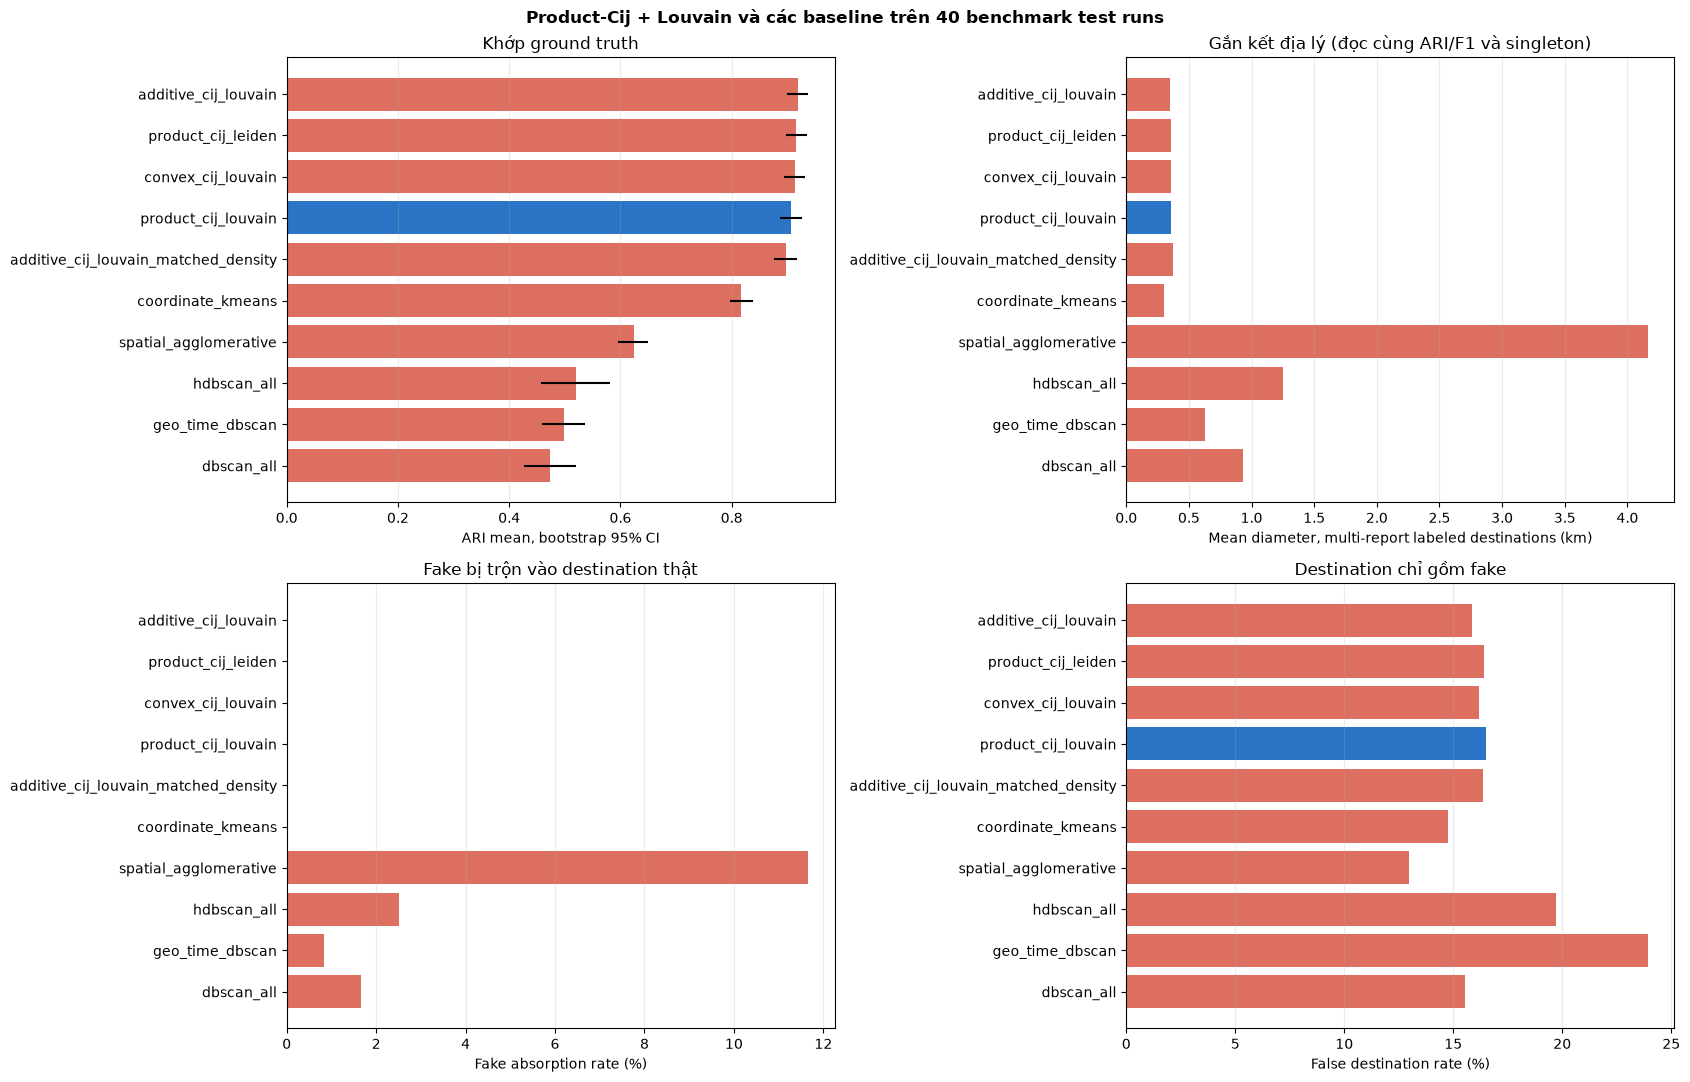

Đã lưu: /content/drive/MyDrive/Colab Notebooks/data/cij_baseline_benchmark_results/cij_baseline_benchmark.png
Đọc fake_rejection_rate cùng genuine_rejection_rate trong benchmark_summary.csv; thấp ở một cột không đủ để kết luận.


In [7]:
# Tổng hợp bằng bootstrap 95% CI thống nhất cho mọi mean.
PRIMARY='product_cij_louvain'
def bootstrap_mean_ci(values,seed,n_boot=10000):
    values=np.asarray(values,dtype=float); rng_local=np.random.default_rng(seed)
    means=np.mean(rng_local.choice(values,size=(n_boot,len(values)),replace=True),axis=1)
    return float(values.mean()),float(np.quantile(means,.025)),float(np.quantile(means,.975))

summary_rows=[]
for method_index,method in enumerate(METHODS):
    block=test_df[test_df.method==method]
    ari_mean,ari_low,ari_high=bootstrap_mean_ci(block.ari,20260812+method_index)
    summary_rows.append({'method':method,'ari_mean':ari_mean,'ari_ci95_low':ari_low,'ari_ci95_high':ari_high,
      'nmi_mean':float(block.nmi.mean()),'pair_f1_mean':float(block.pair_f1.mean()),
      'mean_diameter_km':float(block.mean_diameter_km.mean()),
      'max_diameter_km':float(block.max_diameter_km.mean()),
      'fake_absorption_rate':float(block.fake_absorption_rate.mean()),
      'fake_rejection_rate':float(block.fake_rejection_rate.mean()),
      'false_destination_rate':float(block.false_destination_rate.mean()),
      'fake_only_destinations':float(block.fake_only_destinations.mean()),
      'genuine_rejection_rate':float(block.genuine_rejection_rate.mean()),
      'unassigned_genuine_reports':float(block.unassigned_genuine_reports.mean()),
      'n_singletons':float(block.n_singletons.mean()),
      'retained_edge_fraction':float(block.retained_edge_fraction.mean()) if block.retained_edge_fraction.notna().any() else np.nan,
      'mean_degree':float(block.mean_degree.mean()) if block.mean_degree.notna().any() else np.nan,
      'runtime_seconds':float(block.runtime_seconds.mean())})
summary=pd.DataFrame(summary_rows)
display(summary.sort_values('ari_mean',ascending=False))

rng=np.random.default_rng(20260812); comparisons=[]
primary=test_df[test_df.method==PRIMARY].set_index('run_id')
for method in METHODS:
    if method==PRIMARY:continue
    other=test_df[test_df.method==method].set_index('run_id'); delta=(primary.ari-other.ari).to_numpy()
    boot=np.mean(rng.choice(delta,size=(10000,len(delta)),replace=True),axis=1)
    try:p=float(wilcoxon(delta).pvalue) if np.any(delta!=0) else 1.0
    except ValueError:p=1.0
    comparisons.append({'baseline':method,'mean_delta_ari':float(delta.mean()),
      'ci95_low':float(np.quantile(boot,.025)),'ci95_high':float(np.quantile(boot,.975)),
      'wins':int(np.sum(delta>0)),'ties':int(np.sum(delta==0)),'losses':int(np.sum(delta<0)),
      'wilcoxon_p_raw':p})
comparison_df=pd.DataFrame(comparisons).sort_values('wilcoxon_p_raw')
# Holm adjustment cho nhiều baseline.
m=len(comparison_df); adjusted=np.maximum.accumulate(np.minimum(1.0,(m-np.arange(m))*comparison_df.wilcoxon_p_raw.to_numpy()))
comparison_df['wilcoxon_p_holm']=adjusted
display(comparison_df)
SUMMARY_PATH=RESULTS_ROOT/'benchmark_summary.csv'; COMP_PATH=RESULTS_ROOT/'paired_comparisons.csv'
summary.to_csv(SUMMARY_PATH,index=False); comparison_df.to_csv(COMP_PATH,index=False)

# Báo cáo riêng mức matched-density đạt được trên test (không dùng test để chọn cấu hình).
MATCH_METHODS=[PRIMARY,'additive_cij_louvain_matched_density']
matched_density_test=test_df[test_df.method.isin(MATCH_METHODS)].groupby('method').agg(
    retained_edge_fraction=('retained_edge_fraction','mean'),mean_degree=('mean_degree','mean'),
    n_edges=('n_edges','mean'),ari=('ari','mean'),mean_diameter_km=('mean_diameter_km','mean')).reset_index()
MATCH_TEST_PATH=RESULTS_ROOT/'matched_density_test_diagnostics.csv'
matched_density_test.to_csv(MATCH_TEST_PATH,index=False)
display(matched_density_test)

FIG_PATH=RESULTS_ROOT/'cij_baseline_benchmark.png'
order=summary.sort_values('ari_mean',ascending=True); colors=['#1565c0' if name==PRIMARY else '#d95f4f' for name in order.method]
fig,axes=plt.subplots(2,2,figsize=(17,11))
ari_err=np.vstack([order.ari_mean-order.ari_ci95_low,order.ari_ci95_high-order.ari_mean])
axes[0,0].barh(order.method,order.ari_mean,xerr=ari_err,color=colors,alpha=.9);axes[0,0].set(xlabel='ARI mean, bootstrap 95% CI',title='Khớp ground truth')
axes[0,1].barh(order.method,order.mean_diameter_km,color=colors,alpha=.9);axes[0,1].set(xlabel='Mean diameter, multi-report labeled destinations (km)',title='Gắn kết địa lý (đọc cùng ARI/F1 và singleton)')
axes[1,0].barh(order.method,order.fake_absorption_rate,color=colors,alpha=.9);axes[1,0].set(xlabel='Fake absorption rate (%)',title='Fake bị trộn vào destination thật')
axes[1,1].barh(order.method,order.false_destination_rate,color=colors,alpha=.9);axes[1,1].set(xlabel='False destination rate (%)',title='Destination chỉ gồm fake')
for ax in axes.flat:ax.grid(axis='x',alpha=.25)
fig.suptitle('Product-Cij + Louvain và các baseline trên 40 benchmark test runs',fontweight='bold')
fig.tight_layout();fig.savefig(FIG_PATH,dpi=180,bbox_inches='tight');plt.show()
print('Đã lưu:',FIG_PATH)
print('Đọc fake_rejection_rate cùng genuine_rejection_rate trong benchmark_summary.csv; thấp ở một cột không đủ để kết luận.')


## Cách kết luận

Không kết luận chỉ từ việc phương pháp nào đứng đầu ARI. Với mỗi baseline, xem `mean_delta_ari = ARI_product − ARI_baseline`:

- CI 95% hoàn toàn lớn hơn 0 và Holm-$p<0.05$: có bằng chứng product tốt hơn baseline đó về ARI trên benchmark này.
- CI chứa 0: chưa đủ bằng chứng khác biệt.
- CI hoàn toàn nhỏ hơn 0: product kém baseline đó về ARI.

Có hai dòng Additive với ý nghĩa khác nhau:

- `additive_cij_louvain`: pipeline được tuning độc lập; trả lời hiệu quả tổng thể sau calibration. Cấu hình JSON công bố rõ $\alpha$; $\beta=\gamma=0.5$, nên $\alpha=1$ không có nghĩa equal weights.
- `additive_cij_louvain_matched_density`: dùng cùng $\sigma,\tau_t$, resolution và $\alpha=\beta=\gamma=0.5$; chỉ $q/k$ được chọn không dùng nhãn để khớp retained-edge fraction và mean degree của Product. Đây là sensitivity analysis gần hơn với ảnh hưởng nhân–cộng.

Đường kính thấp chỉ tốt khi ARI/F1 vẫn cao và số singleton không tăng bất thường. Với fake/noise phải đọc đồng thời `fake_absorption_rate`, `false_destination_rate`, `fake_rejection_rate` và `genuine_rejection_rate`; không cột nào một mình chứng minh thuật toán xử lý noise tốt.

Notebook không đánh giá priority. Không được dùng các kết quả này để tuyên bố priority score tốt hơn legacy/linear/random; việc đó cần outcome độc lập và một benchmark riêng.


In [8]:
from google.colab import files
for path in [DEV_AUDIT_PATH,TUNING_PATH,MATCH_CAL_PATH,CONFIG_PATH,TEST_PATH,
             SUMMARY_PATH,COMP_PATH,MATCH_TEST_PATH,FIG_PATH]:
    files.download(str(path))


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>